In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
df=pd.read_csv("placement.csv")

In [7]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [8]:
df.shape

(100, 4)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [10]:
df=df.iloc[:,1:]

In [11]:
df

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


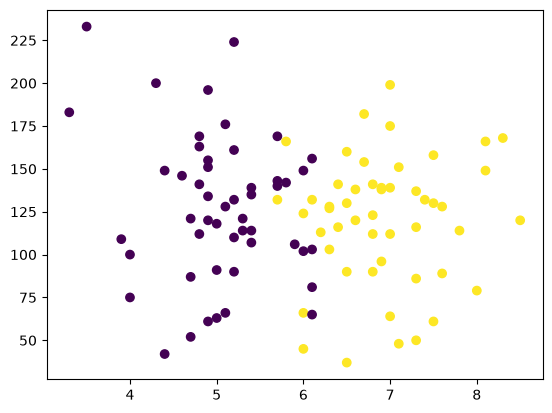

In [12]:
plt.scatter(df["cgpa"],df["iq"],c=df['placement'])

In [13]:
X=df.iloc[:,0:2]
Y=df.iloc[:,-1]

In [14]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [15]:
Y.shape

(100,)

In [16]:
Y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [17]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train , Y_test=train_test_split(X,Y,test_size=0.1)

In [18]:
X_train

,cgpa,iq
10,6.0,45.0
87,5.7,132.0
64,7.0,64.0
51,4.8,141.0
85,5.8,166.0
...,...,...
82,6.5,37.0
36,5.7,140.0
67,5.0,118.0
90,7.3,86.0


In [19]:
X_test

,cgpa,iq
94,4.7,52.0
86,5.1,128.0
35,6.8,90.0
9,5.1,66.0
28,5.2,90.0
97,6.7,182.0
14,6.1,103.0
31,3.9,109.0
2,5.3,121.0
71,6.1,132.0


In [20]:
from sklearn.preprocessing import StandardScaler

In [21]:
scaler =StandardScaler()

In [22]:
X_train=scaler.fit_transform(X_train)

In [23]:
X_train

array([[-0.03956731, -2.01798351],
       [-0.30013252,  0.16595718],
       [ 0.82898338, -1.54103095],
       [-1.08182813,  0.39188208],
       [-0.21327745,  1.01945124],
       [ 0.2209979 ,  0.06554611],
       [ 0.13414283, -0.31099539],
       [ 0.65527324, -0.33609815],
       [-0.99497306,  0.64290974],
       [-0.73440786, -0.38630369],
       [-0.73440786,  0.89393741],
       [ 0.04728776,  0.76842358],
       [-1.1686832 , -0.11017325],
       [ 0.30785297, -0.23568709],
       [-0.908118  , -1.56613372],
       [-1.08182813,  0.94414294],
       [ 0.82898338,  0.34167655],
       [-0.73440786,  2.4754117 ],
       [ 2.13180941, -0.13527602],
       [ 0.74212831,  0.31657378],
       [-0.64755279, -0.28589262],
       [ 1.26325872,  0.81862911],
       [-0.82126293,  1.27047891],
       [ 0.82898338,  1.24537614],
       [-1.51610348,  1.87294531],
       [ 0.4815631 ,  0.31657378],
       [ 0.39470803, -0.88835902],
       [ 1.35011379, -0.91346178],
       [-0.99497306,

In [24]:
X_test=scaler.fit_transform(X_test)

In [25]:
X_test

array([[-0.92376043, -1.58387716],
       [-0.46188022,  0.59287988],
       [ 1.5011107 , -0.49549864],
       [-0.46188022, -1.1828956 ],
       [-0.34641016, -0.49549864],
       [ 1.38564065,  2.13952304],
       [ 0.69282032, -0.12315862],
       [-1.84752086,  0.04869062],
       [-0.23094011,  0.3923891 ],
       [ 0.69282032,  0.70744604]])

In [26]:
from sklearn.linear_model import LogisticRegression

In [27]:
clf=LogisticRegression()

In [28]:
clf.fit(X_train,Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [29]:
Y_pred=clf.predict(X_test)

In [30]:
Y_test

94    0
86    0
35    1
9     0
28    0
97    1
14    0
31    0
2     0
71    1
Name: placement, dtype: int64

In [31]:
from sklearn.metrics import accuracy_score

In [32]:
accuracy_score(Y_test,Y_pred)*100

90.0

In [33]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

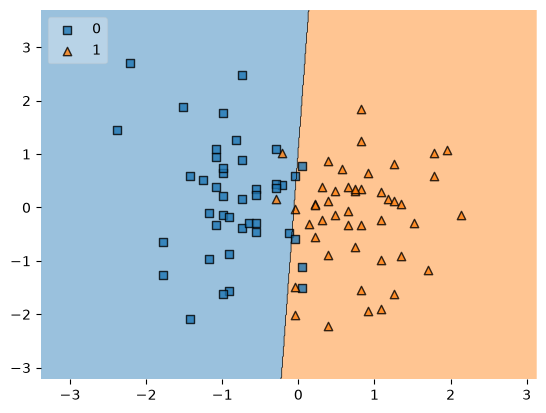

In [34]:
plot_decision_regions(X_train , Y_train.values,clf=clf , legend=2)

In [35]:
import pickle

In [36]:
pickle.dump(clf,open("model.pkl","wb"))